# Bursa Smart Home Finder — Exploratory Data Analysis

Synthetic raw listings dataset (`data/raw/bursa_listings_synthetic.csv`) generated by `src/data_prep.py::generate_raw_listings`. See `02_feature_engineering.ipynb` for the transformation into the 0-1 normalized `district`/`budget`/`transport`/... schema consumed by `src/scoring.py` and `src/recommender.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path("..") / "data"
listings = pd.read_csv(DATA_DIR / "raw" / "bursa_listings_synthetic.csv")
listings.shape

(1200, 15)

In [2]:
listings.head()

,listing_id,district,room_count,area,building_age,floor,total_floors,price,distance_to_university_km,distance_to_center_km,distance_to_hospital_km,green_space_score,safety_score,public_transport_score,noise_level
0,1,Görükle,3+1,124.8,20,1,7,14860.0,0.0,13.4,6.0,7.4,6.6,6.7,6.1
1,2,Görükle,2+1,75.8,2,2,4,15840.0,0.0,15.0,5.3,6.7,6.7,5.9,6.5
2,3,Görükle,3+1,128.1,2,0,7,18200.0,0.0,14.2,7.3,6.1,6.4,6.2,7.7
3,4,Görükle,3+1,123.2,22,2,6,17170.0,3.3,14.2,5.0,4.9,7.5,7.2,6.3
4,5,Görükle,1+1,48.6,2,8,9,9460.0,0.0,14.8,5.7,6.0,6.4,6.2,7.8


In [3]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   listing_id                 1200 non-null   int64  
 1   district                   1200 non-null   object 
 2   room_count                 1200 non-null   object 
 3   area                       1200 non-null   float64
 4   building_age               1200 non-null   int64  
 5   floor                      1200 non-null   int64  
 6   total_floors               1200 non-null   int64  
 7   price                      1200 non-null   float64
 8   distance_to_university_km  1200 non-null   float64
 9   distance_to_center_km      1200 non-null   float64
 10  distance_to_hospital_km    1200 non-null   float64
 11  green_space_score          1200 non-null   float64
 12  safety_score               1200 non-null   float64
 13  public_transport_score     1200 non-null   float

In [4]:
listings.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_id,1200.0,600.500000,346.554469,1.0,300.750,600.50,900.25,1200.0
area,1200.0,90.848917,31.133196,45.0,64.875,85.60,111.80,169.9
building_age,1200.0,7.575833,8.154835,0.0,2.000,5.00,10.00,60.0
floor,1200.0,3.505000,2.628510,0.0,1.000,3.00,5.00,11.0
total_floors,1200.0,7.000833,2.564757,3.0,5.000,7.00,9.00,11.0
price,1200.0,18555.900000,7825.973469,5120.0,12740.000,17190.00,22647.50,57250.0
distance_to_university_km,1200.0,8.912667,6.057360,0.0,4.800,8.20,11.10,26.5
distance_to_center_km,1200.0,8.203833,5.907027,0.0,4.200,6.80,11.50,23.7
distance_to_hospital_km,1200.0,3.982833,2.196701,0.0,2.400,3.75,5.30,9.9
green_space_score,1200.0,6.364250,1.472284,2.7,5.300,6.30,7.40,10.0


In [5]:
listings.isna().sum()

listing_id                   0
district                     0
room_count                   0
area                         0
building_age                 0
floor                        0
total_floors                 0
price                        0
distance_to_university_km    0
distance_to_center_km        0
distance_to_hospital_km      0
green_space_score            0
safety_score                 0
public_transport_score       0
noise_level                  0
dtype: int64

## Price distribution by district

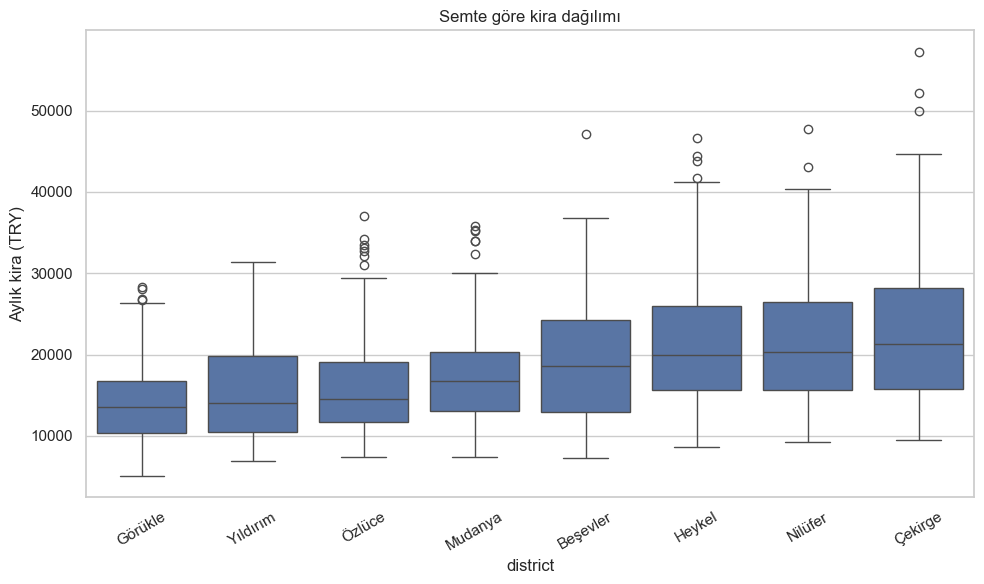

In [6]:
order = listings.groupby("district")["price"].median().sort_values().index

plt.figure(figsize=(10, 6))
sns.boxplot(data=listings, x="district", y="price", order=order)
plt.xticks(rotation=30)
plt.ylabel("Aylık kira (TRY)")
plt.title("Semte göre kira dağılımı")
plt.tight_layout()
plt.show()

## Room type mix

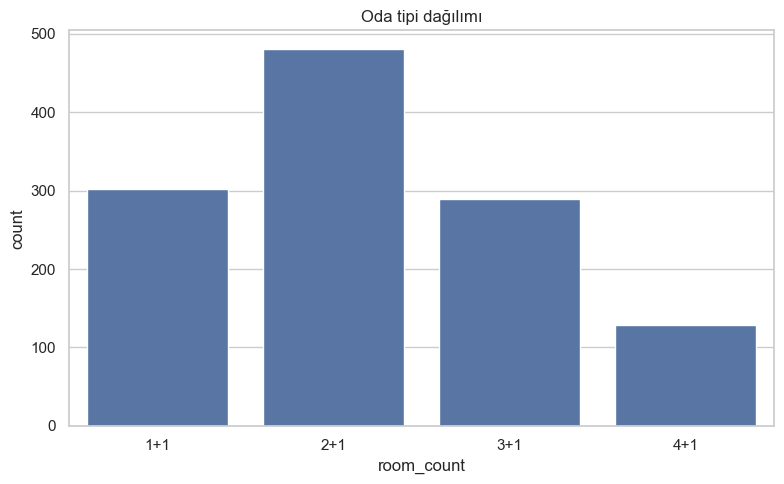

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=listings, x="room_count", order=["1+1", "2+1", "3+1", "4+1"])
plt.title("Oda tipi dağılımı")
plt.tight_layout()
plt.show()

## District profile comparison

In [8]:
profile_cols = [
    "price",
    "distance_to_university_km",
    "distance_to_center_km",
    "green_space_score",
    "safety_score",
    "public_transport_score",
    "noise_level",
]
listings.groupby("district")[profile_cols].mean().round(1)

,price,distance_to_university_km,distance_to_center_km,green_space_score,safety_score,public_transport_score,noise_level
district,,,,,,,
Beşevler,19218.5,3.9,5.9,6.0,7.5,8.6,6.0
Görükle,13999.9,1.1,14.0,5.9,6.6,6.0,6.5
Heykel,21870.5,9.8,0.7,4.5,6.4,9.0,8.0
Mudanya,17307.9,22.0,20.0,8.5,7.5,4.0,3.0
Nilüfer,21831.1,7.8,7.0,7.5,8.0,7.5,4.6
Yıldırım,15151.7,11.8,6.0,5.0,6.0,6.0,6.1
Çekirge,22988.5,9.0,3.0,7.0,8.5,6.9,5.0
Özlüce,16079.1,5.9,9.1,6.5,7.0,6.5,5.1


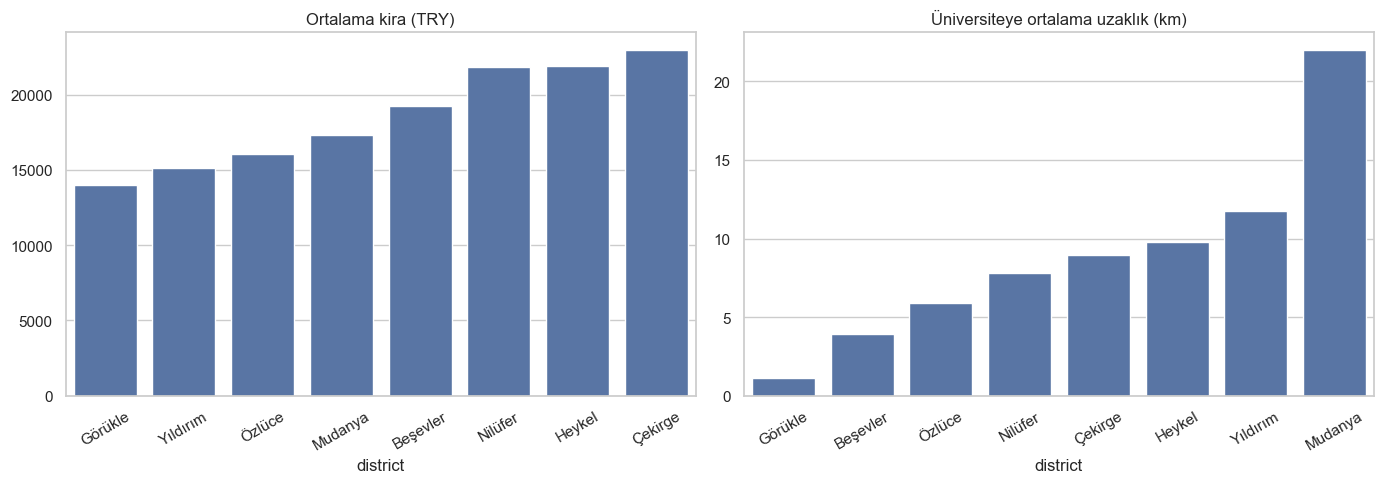

In [9]:
district_price = listings.groupby("district")["price"].mean().sort_values()
district_uni = listings.groupby("district")["distance_to_university_km"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=district_price.index, y=district_price.values, ax=axes[0])
axes[0].set_title("Ortalama kira (TRY)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=district_uni.index, y=district_uni.values, ax=axes[1])
axes[1].set_title("Üniversiteye ortalama uzaklık (km)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Correlations between numeric features

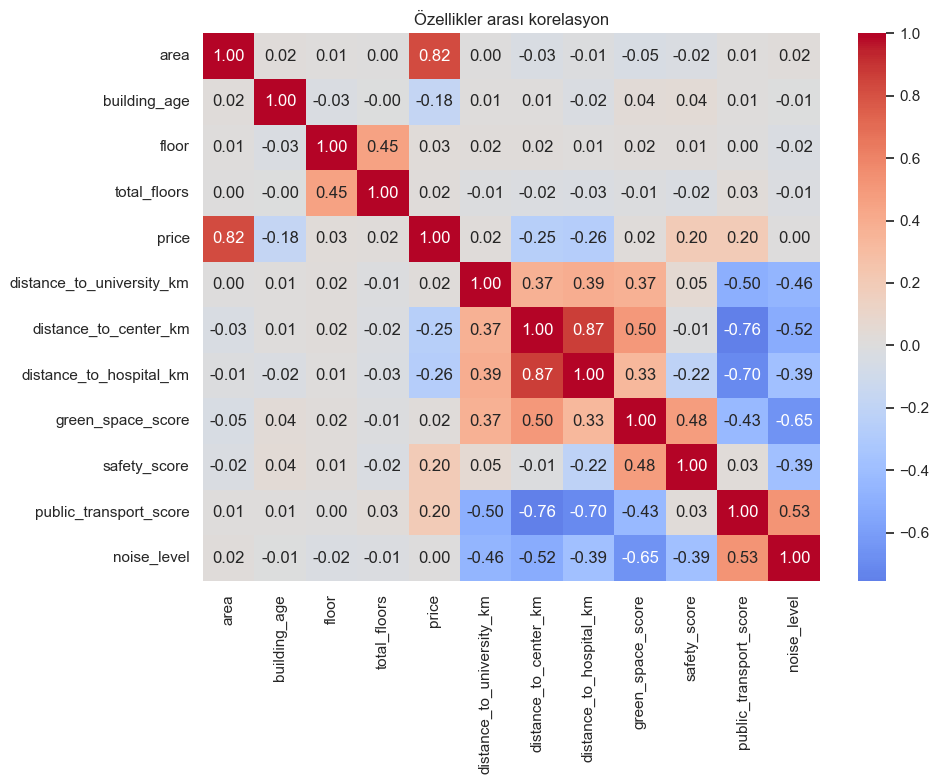

In [10]:
numeric_cols = listings.select_dtypes(include=[np.number]).drop(columns=["listing_id"])
corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Özellikler arası korelasyon")
plt.tight_layout()
plt.show()

## Price vs. distance to university

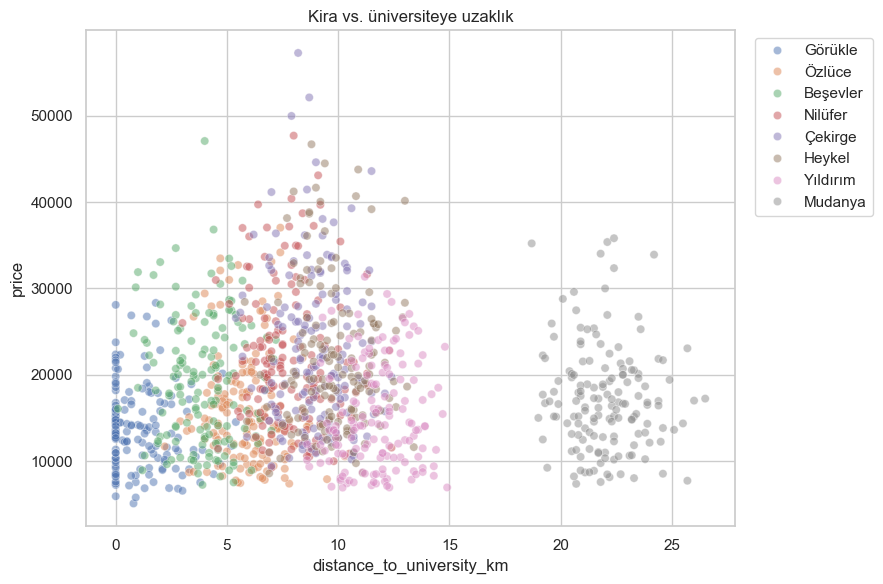

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=listings,
    x="distance_to_university_km",
    y="price",
    hue="district",
    alpha=0.5,
)
plt.title("Kira vs. üniversiteye uzaklık")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Notes for feature engineering / scoring

- `price` sağa çarpık (building_age ve area etkisiyle) — feature engineering'de min-max normalize edilerek `budget` alt skoruna çevriliyor (bkz. `02_feature_engineering.ipynb`).
- `distance_to_university_km` ile `price` arasında negatif ilişki (üniversiteye yakın ucuz — öğrenci bölgesi Görükle) dikkat çekici; `distance` alt skoru bunu yakalıyor.
- `green_space_score`, `safety_score`, `public_transport_score`, `noise_level` doğrudan `social`/`safety`/`transport` alt skorlarına giriyor.